# Assignment: Trader Performance vs Bitcoin Market Sentiment

In [42]:
# Core imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', context='notebook')

In [43]:
# Load datasets (will download from Google Drive if missing)
import os
def _download_if_missing(path, drive_id):
    if os.path.exists(path):
        return
    try:
        import gdown
    except Exception:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gdown', '--quiet'])
        import gdown
    url = f'https://drive.google.com/uc?id={drive_id}'
    print(f'Downloading {path} from Drive...')
    gdown.download(url, path, quiet=False)

# Replace these IDs with the shared-drive IDs provided
HISTORICAL_DRIVE_ID = '1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs'
FG_DRIVE_ID = '1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf'

fear_greed_path = 'fear_greed_index.csv'
trades_path = 'historical_data.csv'

# Attempt download if files are not present locally
_download_if_missing(trades_path, HISTORICAL_DRIVE_ID)
_download_if_missing(fear_greed_path, FG_DRIVE_ID)

# Read CSVs (fall back will raise if files still missing)
sentiment_raw = pd.read_csv(fear_greed_path)
trades_raw = pd.read_csv(trades_path)

print('Sentiment shape:', sentiment_raw.shape)
print('Trades shape:', trades_raw.shape)

display(sentiment_raw.head())
display(trades_raw.head())

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [44]:
# Standardize and clean sentiment data
sentiment = sentiment_raw.copy()
sentiment.columns = [c.strip().lower().replace(' ', '_') for c in sentiment.columns]

sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
sentiment['value'] = pd.to_numeric(sentiment['value'], errors='coerce')
sentiment['classification'] = sentiment['classification'].astype(str).str.strip()

sentiment = sentiment.dropna(subset=['date', 'classification']).drop_duplicates(subset=['date'])

print('Sentiment cleaned shape:', sentiment.shape)
print('Missing values in sentiment:')
display(sentiment.isna().sum())
display(sentiment.head())

Sentiment cleaned shape: (2644, 4)
Missing values in sentiment:


,0
timestamp,0
value,0
classification,0
date,0


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [45]:
# Standardize and clean trade data
trades = trades_raw.copy()
trades.columns = [c.strip().lower().replace(' ', '_') for c in trades.columns]

# Parse timestamps (Timestamp IST is in day-first format like 02-12-2024 22:50)
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True, errors='coerce')
trades['date'] = trades['timestamp_ist'].dt.normalize()

numeric_cols = [
    'execution_price', 'size_tokens', 'size_usd', 'start_position',
    'closed_pnl', 'fee', 'timestamp'
]
for col in numeric_cols:
    if col in trades.columns:
        trades[col] = pd.to_numeric(trades[col], errors='coerce')

if 'side' in trades.columns:
    trades['side'] = trades['side'].astype(str).str.upper().str.strip()

if 'direction' in trades.columns:
    trades['direction'] = trades['direction'].astype(str).str.upper().str.strip()

trades = trades.dropna(subset=['timestamp_ist', 'date'])

print('Trades cleaned shape:', trades.shape)
print('Missing values in trades (top 15 columns):')
display(trades.isna().sum().sort_values(ascending=False).head(15))
display(trades.head())

Trades cleaned shape: (211224, 17)
Missing values in trades (top 15 columns):


,0
account,0
coin,0
execution_price,0
size_tokens,0
size_usd,0
side,0
timestamp_ist,0
start_position,0
direction,0
closed_pnl,0


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,BUY,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,BUY,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,BUY,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,BUY,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,BUY,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [46]:
# Merge trades with daily sentiment
merged = trades.merge(
    sentiment[['date', 'classification', 'value']],
    on='date',
    how='left'
)

merged = merged.rename(columns={
    'classification': 'sentiment_class',
    'value': 'sentiment_value'
})

# Keep only rows where sentiment exists to analyze sentiment-performance relationship
analysis_df = merged.dropna(subset=['sentiment_class']).copy()

print('Merged shape:', merged.shape)
print('Rows with matched sentiment:', analysis_df.shape[0])
print('Sentiment coverage:', round(100 * analysis_df.shape[0] / merged.shape[0], 2), '%')

display(analysis_df[['date', 'coin', 'side', 'closed_pnl', 'size_usd', 'sentiment_class', 'sentiment_value']].head())

Merged shape: (211224, 19)
Rows with matched sentiment: 211218
Sentiment coverage: 100.0 %


,date,coin,side,closed_pnl,size_usd,sentiment_class,sentiment_value
0,2024-12-02,@107,BUY,0.0,7872.16,Extreme Greed,80.0
1,2024-12-02,@107,BUY,0.0,127.68,Extreme Greed,80.0
2,2024-12-02,@107,BUY,0.0,1150.63,Extreme Greed,80.0
3,2024-12-02,@107,BUY,0.0,1142.04,Extreme Greed,80.0
4,2024-12-02,@107,BUY,0.0,69.75,Extreme Greed,80.0


,pnl,trade_notional,fee_paid,is_win,net_pnl,sentiment_class,hour_ist
0,0.0,7872.16,0.345404,0,-0.345404,Extreme Greed,22
1,0.0,127.68,0.005600,0,-0.005600,Extreme Greed,22
2,0.0,1150.63,0.050431,0,-0.050431,Extreme Greed,22
3,0.0,1142.04,0.050043,0,-0.050043,Extreme Greed,22
4,0.0,69.75,0.003055,0,-0.003055,Extreme Greed,22


ML rows available: 211218
Classifier accuracy: 0.7135451188334438
              precision    recall  f1-score   support

           0       0.71      0.86      0.78     24871
           1       0.72      0.50      0.59     17373

    accuracy                           0.71     42244
   macro avg       0.72      0.68      0.68     42244
weighted avg       0.71      0.71      0.70     42244



<Figure size 800x600 with 0 Axes>

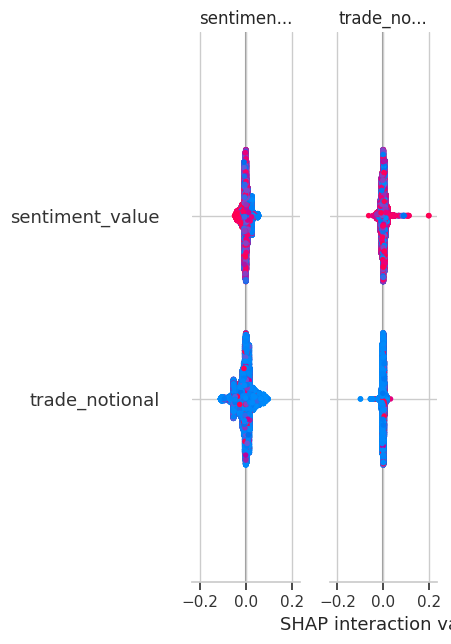

Regressor RMSE: 627.0204737626211
Regressor R2: 0.14682065347519024


In [47]:
# Helper columns for performance/risk analysis
analysis_df['pnl'] = pd.to_numeric(analysis_df['closed_pnl'], errors='coerce').fillna(0.0)
analysis_df['trade_notional'] = pd.to_numeric(analysis_df['size_usd'], errors='coerce')
analysis_df['fee_paid'] = pd.to_numeric(analysis_df['fee'], errors='coerce').fillna(0.0)
analysis_df['net_pnl'] = analysis_df['pnl'] - analysis_df['fee_paid']
analysis_df['is_win'] = (analysis_df['pnl'] > 0).astype(int)
analysis_df['is_loss'] = (analysis_df['pnl'] < 0).astype(int)
analysis_df['abs_pnl'] = analysis_df['pnl'].abs()
analysis_df['hour_ist'] = analysis_df['timestamp_ist'].dt.hour

# Stable sentiment order for comparisons
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
analysis_df['sentiment_class'] = pd.Categorical(
    analysis_df['sentiment_class'],
    categories=sentiment_order,
    ordered=True
)

display(analysis_df[['pnl', 'trade_notional', 'fee_paid', 'is_win', 'net_pnl', 'sentiment_class', 'hour_ist']].head())

# -----------------------------
# Simple ML: predict per-trade profitability and explain with SHAP
# -----------------------------
# Prepare a lightweight feature set
ml_df = analysis_df.copy()
ml_df['label_win'] = (ml_df['pnl'] > 0).astype(int)
# Basic numeric features
ml_df['sentiment_value'] = pd.to_numeric(ml_df['sentiment_value'], errors='coerce')
features = ['sentiment_value', 'trade_notional', 'fee_paid']
# Side encoding
ml_df['side_buy'] = (ml_df['side'] == 'BUY').astype(int)
features += ['side_buy']
# Limit coin categories to top N and one-hot encode
TOP_COINS = 20
top_coins = ml_df['coin'].value_counts().nlargest(TOP_COINS).index.tolist()
ml_df['coin_top'] = ml_df['coin'].where(ml_df['coin'].isin(top_coins), 'OTHER')
ml_df = pd.get_dummies(ml_df, columns=['coin_top'], prefix='coin')
coin_cols = [c for c in ml_df.columns if c.startswith('coin_')]
features += coin_cols

# Drop rows with missing values in features/label
ml_df = ml_df.dropna(subset=features + ['label_win'])
print('ML rows available:', len(ml_df))

# Train/test split
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
X = ml_df[features]
y_clf = ml_df['label_win']
X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf if y_clf.nunique()>1 else None)
clf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print('Classifier accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# SHAP explainability (install if missing)
try:
    import shap
except Exception:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '--quiet'])
    import shap

# Use TreeExplainer for tree models
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# Plot SHAP summary (works in notebook)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

# Optional: small regressor to predict pnl magnitude
if 'pnl' in ml_df.columns and ml_df['pnl'].notna().any():
    y_reg = ml_df['pnl']
    Xr = ml_df[features].copy()
    Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, y_reg, test_size=0.2, random_state=42)
    reg = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
    reg.fit(Xr_train, yr_train)
    yr_pred = reg.predict(Xr_test)
    print('Regressor RMSE:', np.sqrt(mean_squared_error(yr_test, yr_pred)))
    print('Regressor R2:', r2_score(yr_test, yr_pred))

## Sentiment Distribution During Trading Activity

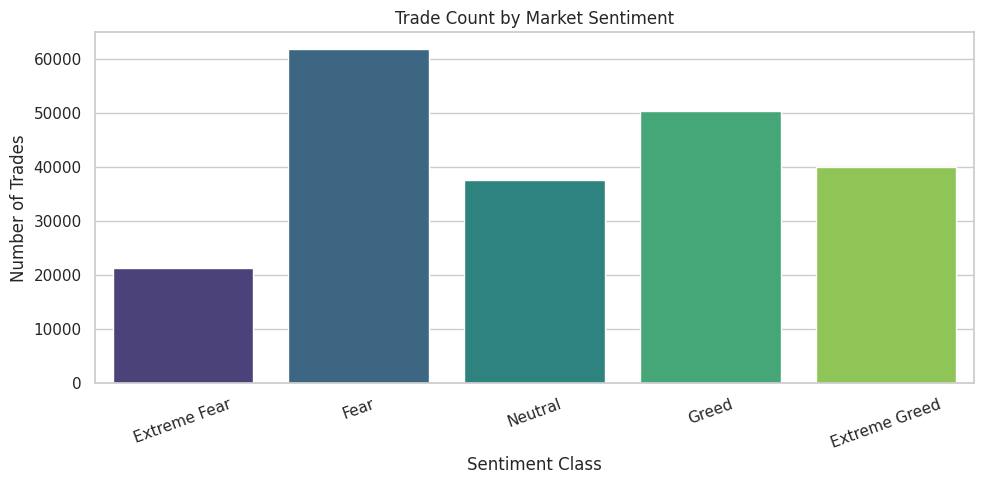

,trade_count
sentiment_class,
Extreme Fear,21400
Fear,61837
Neutral,37686
Greed,50303
Extreme Greed,39992


In [48]:
plt.figure(figsize=(10, 5))
sentiment_counts = analysis_df['sentiment_class'].value_counts().reindex(sentiment_order)
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Trade Count by Market Sentiment')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Trades')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(sentiment_counts.to_frame('trade_count'))

## Core Performance Metrics by Sentiment

In [49]:
perf_by_sentiment = analysis_df.groupby('sentiment_class', observed=False).agg(
    trades=('pnl', 'size'),
    total_pnl=('pnl', 'sum'),
    avg_pnl=('pnl', 'mean'),
    median_pnl=('pnl', 'median'),
    win_rate=('is_win', 'mean'),
    avg_notional=('trade_notional', 'mean'),
    total_fees=('fee_paid', 'sum')
).reset_index()

perf_by_sentiment['win_rate'] = perf_by_sentiment['win_rate'] * 100
perf_by_sentiment = perf_by_sentiment.sort_values('sentiment_class')

display(perf_by_sentiment.style.format({
    'total_pnl': '{:,.2f}',
    'avg_pnl': '{:,.4f}',
    'median_pnl': '{:,.4f}',
    'win_rate': '{:.2f}%',
    'avg_notional': '{:,.2f}',
    'total_fees': '{:,.2f}'
}))

,sentiment_class,trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_notional,total_fees
0,Extreme Fear,21400,"739,110.25",34.5379,0.0000,37.06%,"5,349.73","23,888.63"
1,Fear,61837,"3,357,155.44",54.2904,0.0000,42.08%,"7,816.11","92,456.95"
2,Neutral,37686,"1,292,920.68",34.3077,0.0000,39.70%,"4,782.73","39,374.27"
3,Greed,50303,"2,150,129.27",42.7436,0.0000,38.48%,"5,736.88","63,098.69"
4,Extreme Greed,39992,"2,715,171.31",67.8929,0.0000,46.49%,"3,112.25","27,030.67"


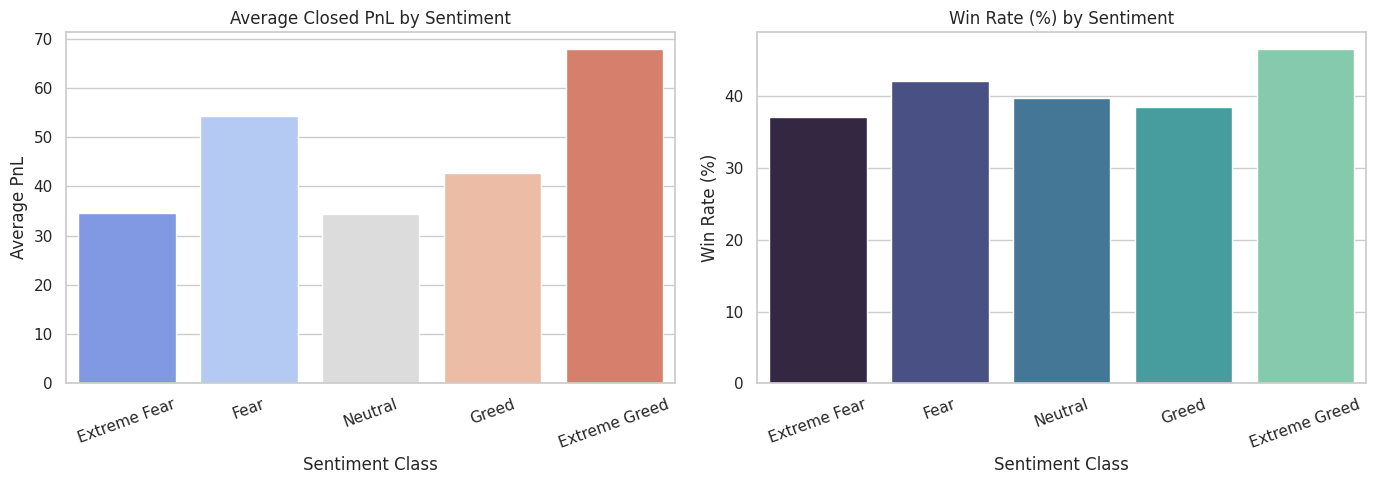

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=perf_by_sentiment, x='sentiment_class', y='avg_pnl', palette='coolwarm', ax=axes[0])
axes[0].set_title('Average Closed PnL by Sentiment')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Average PnL')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=perf_by_sentiment, x='sentiment_class', y='win_rate', palette='mako', ax=axes[1])
axes[1].set_title('Win Rate (%) by Sentiment')
axes[1].set_xlabel('Sentiment Class')
axes[1].set_ylabel('Win Rate (%)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Distribution Analysis (Hidden Risk Patterns)

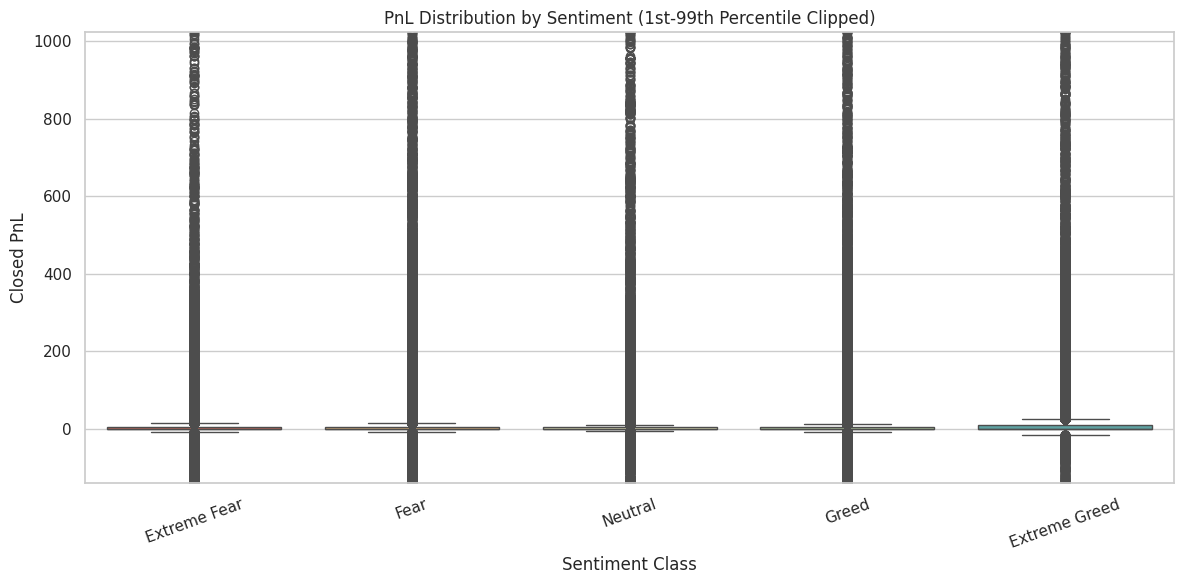

,p5_pnl,p95_pnl
sentiment_class,,
Extreme Fear,-33.674459,179.650728
Fear,-0.717115,156.722996
Neutral,-5.340448,124.258071
Greed,-13.957308,166.108885
Extreme Greed,-0.220510,204.483944


In [51]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=analysis_df, x='sentiment_class', y='pnl', palette='Spectral')
plt.ylim(analysis_df['pnl'].quantile(0.01), analysis_df['pnl'].quantile(0.99))
plt.title('PnL Distribution by Sentiment (1st-99th Percentile Clipped)')
plt.xlabel('Sentiment Class')
plt.ylabel('Closed PnL')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

tail_risk = analysis_df.groupby('sentiment_class', observed=False)['pnl'].quantile([0.05, 0.95]).unstack()
tail_risk.columns = ['p5_pnl', 'p95_pnl']
display(tail_risk)

## Side Behavior by Sentiment (BUY vs SELL)

,sentiment_class,side,trades,avg_pnl,win_rate,avg_notional
0,Extreme Fear,BUY,10935,34.1146,20.16%,"5,161.50"
1,Extreme Fear,SELL,10465,34.9801,54.72%,"5,546.41"
2,Fear,BUY,30270,63.9271,26.30%,"8,154.67"
3,Fear,SELL,31567,45.0496,57.21%,"7,491.46"
4,Neutral,BUY,18969,29.2274,24.00%,"3,881.41"
5,Neutral,SELL,18717,39.4564,55.61%,"5,696.19"
6,Greed,BUY,24576,25.0023,31.81%,"6,306.49"
7,Greed,SELL,25727,59.6911,44.86%,"5,192.76"
8,Extreme Greed,BUY,17940,10.4989,31.14%,"3,363.03"
9,Extreme Greed,SELL,22052,114.5846,58.98%,"2,908.23"


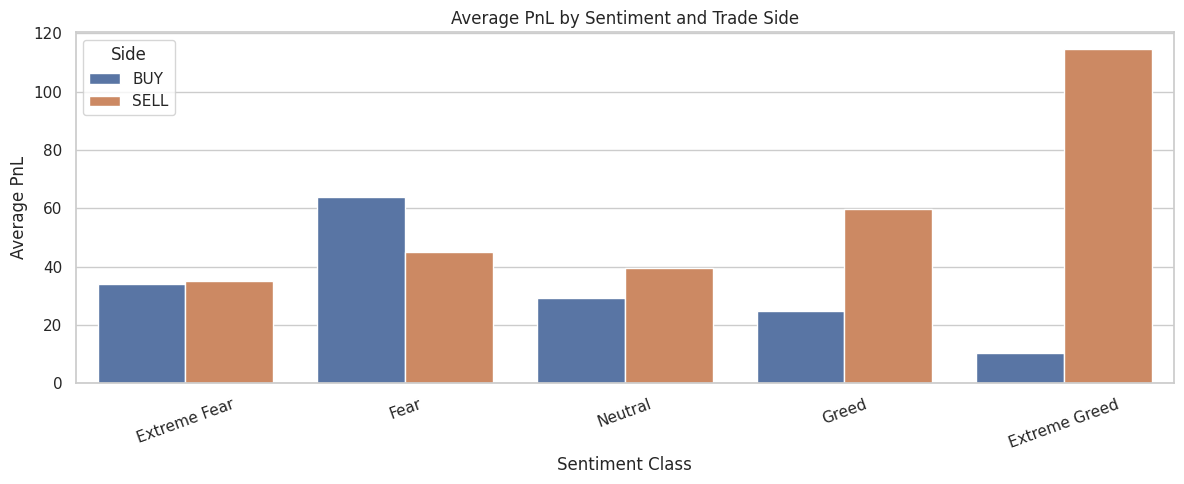

In [52]:
side_perf = analysis_df.groupby(['sentiment_class', 'side'], observed=False).agg(
    trades=('pnl', 'size'),
    avg_pnl=('pnl', 'mean'),
    win_rate=('is_win', 'mean'),
    avg_notional=('trade_notional', 'mean')
).reset_index()
side_perf['win_rate'] = 100 * side_perf['win_rate']

display(side_perf.style.format({
    'avg_pnl': '{:,.4f}',
    'win_rate': '{:.2f}%',
    'avg_notional': '{:,.2f}'
}))

plt.figure(figsize=(12, 5))
sns.barplot(data=side_perf, x='sentiment_class', y='avg_pnl', hue='side')
plt.title('Average PnL by Sentiment and Trade Side')
plt.xlabel('Sentiment Class')
plt.ylabel('Average PnL')
plt.xticks(rotation=20)
plt.legend(title='Side')
plt.tight_layout()
plt.show()

## Account-Level Patterns (Who performs best in each regime?)

,account,total_pnl,trades
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06,14733
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05,21192
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,12236
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05,40184
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05,4356
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05,1590
9,0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,1237
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.790954e+05,9893
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,3.605395e+05,1424


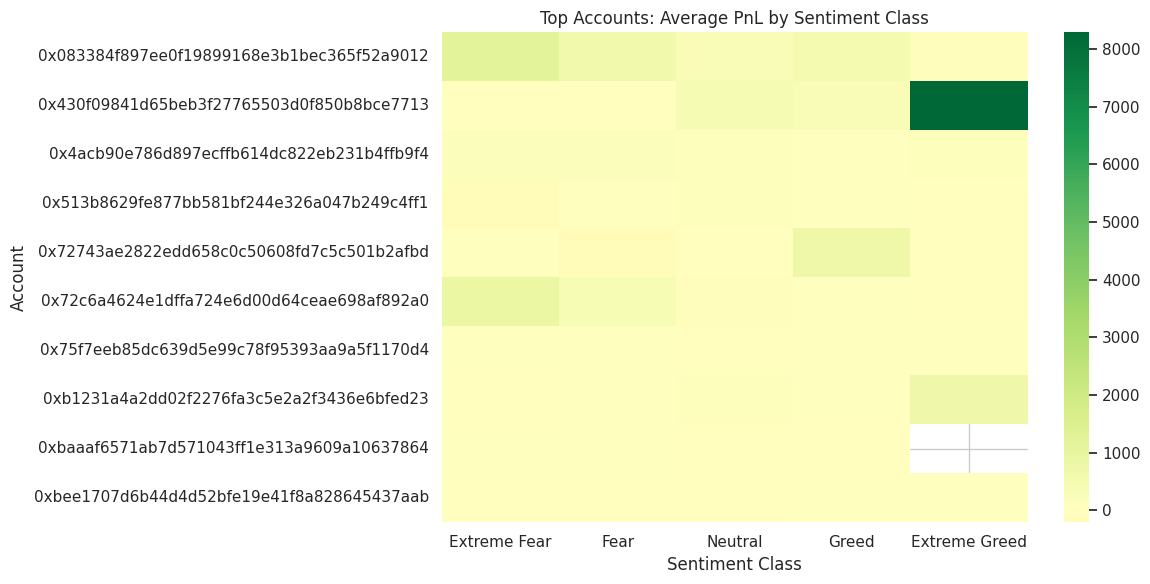

In [53]:
account_sentiment = analysis_df.groupby(['account', 'sentiment_class'], observed=False).agg(
    trades=('pnl', 'size'),
    total_pnl=('pnl', 'sum'),
    avg_pnl=('pnl', 'mean'),
    win_rate=('is_win', 'mean')
).reset_index()

account_sentiment['win_rate'] = 100 * account_sentiment['win_rate']

top_accounts = (
    analysis_df.groupby('account', as_index=False)
    .agg(total_pnl=('pnl', 'sum'), trades=('pnl', 'size'))
    .query('trades >= 20')
    .sort_values('total_pnl', ascending=False)
    .head(10)
)

display(top_accounts)

top10_ids = set(top_accounts['account'])
heat_data = account_sentiment[account_sentiment['account'].isin(top10_ids)]
heat_pivot = heat_data.pivot(index='account', columns='sentiment_class', values='avg_pnl')

plt.figure(figsize=(12, 6))
sns.heatmap(heat_pivot, annot=False, cmap='RdYlGn', center=0)
plt.title('Top Accounts: Average PnL by Sentiment Class')
plt.xlabel('Sentiment Class')
plt.ylabel('Account')
plt.tight_layout()
plt.show()

## Coin-Level Hidden Patterns

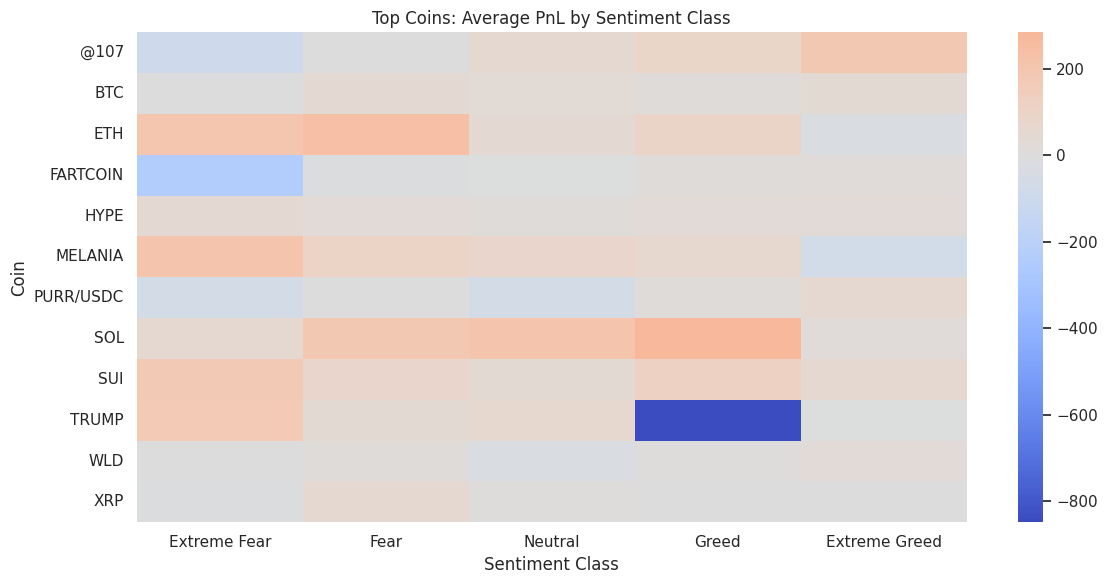

,coin,sentiment_class,trades,total_pnl,avg_pnl
685,HYPE,Extreme Fear,10278,482083.808909,46.904438
600,ETH,Extreme Fear,1393,274320.230690,196.927660
1025,SOL,Extreme Fear,1878,105179.504312,56.006126
805,MELANIA,Extreme Fear,446,97379.167198,218.338940
1050,SUI,Extreme Fear,249,44788.991651,179.875468
1085,TRUMP,Extreme Fear,181,31638.043140,174.795818
480,BERA,Extreme Fear,188,12090.904233,64.313320
745,KAITO,Extreme Fear,105,5172.473377,49.261651
995,RUNE,Extreme Fear,59,3843.260480,65.140008
730,JELLY,Extreme Fear,83,3218.978582,38.782874


In [54]:
coin_sentiment = analysis_df.groupby(['coin', 'sentiment_class'], observed=False).agg(
    trades=('pnl', 'size'),
    total_pnl=('pnl', 'sum'),
    avg_pnl=('pnl', 'mean')
).reset_index()

top_coins = (
    analysis_df.groupby('coin', as_index=False)
    .agg(trades=('pnl', 'size'))
    .sort_values('trades', ascending=False)
    .head(12)['coin']
)

coin_pivot = coin_sentiment[coin_sentiment['coin'].isin(top_coins)].pivot(
    index='coin', columns='sentiment_class', values='avg_pnl'
)

plt.figure(figsize=(12, 6))
sns.heatmap(coin_pivot, cmap='coolwarm', center=0)
plt.title('Top Coins: Average PnL by Sentiment Class')
plt.xlabel('Sentiment Class')
plt.ylabel('Coin')
plt.tight_layout()
plt.show()

display(coin_sentiment.sort_values(['sentiment_class', 'total_pnl'], ascending=[True, False]).head(20))

## Statistical Check: Does PnL Differ Across Sentiment Regimes?

In [55]:
# Non-parametric Kruskal-Wallis test is robust for non-normal PnL distributions
grouped_pnl = [
    g['pnl'].values
    for _, g in analysis_df.groupby('sentiment_class', observed=False)
    if len(g) > 0
]

if len(grouped_pnl) >= 2:
    stat, p_value = stats.kruskal(*grouped_pnl)
    print(f'Kruskal-Wallis H-statistic: {stat:.4f}')
    print(f'p-value: {p_value:.6f}')
    if p_value < 0.05:
        print('Result: Significant difference in PnL distributions across sentiment groups.')
    else:
        print('Result: No statistically significant difference found across sentiment groups.')
else:
    print('Not enough sentiment groups with data for statistical testing.')

Kruskal-Wallis H-statistic: 1226.9956
p-value: 0.000000
Result: Significant difference in PnL distributions across sentiment groups.


## Executive Insights & Strategy Recommendations

In [56]:
summary_tbl = perf_by_sentiment.copy()
summary_tbl = summary_tbl[['sentiment_class', 'trades', 'avg_pnl', 'win_rate', 'avg_notional', 'total_fees']]
display(summary_tbl)

best_avg = summary_tbl.loc[summary_tbl['avg_pnl'].idxmax(), 'sentiment_class'] if not summary_tbl['avg_pnl'].isna().all() else None
worst_avg = summary_tbl.loc[summary_tbl['avg_pnl'].idxmin(), 'sentiment_class'] if not summary_tbl['avg_pnl'].isna().all() else None
best_win = summary_tbl.loc[summary_tbl['win_rate'].idxmax(), 'sentiment_class'] if not summary_tbl['win_rate'].isna().all() else None

print('Key findings:')
print(f'- Best average PnL regime: {best_avg}')
print(f'- Worst average PnL regime: {worst_avg}')
print(f'- Highest win-rate regime: {best_win}')

print('\nPotential strategy improvements:')
print('1. Sentiment-aware position sizing: reduce size in historically weak sentiment regimes.')
print('2. Side selection by regime: tilt more toward the side with stronger avg PnL per sentiment class.')
print('3. Account-level specialization: assign higher capital to accounts with stable positive PnL in specific regimes.')
print('4. Fee-aware execution: monitor whether higher activity in a sentiment regime is offset by fee drag.')

,sentiment_class,trades,avg_pnl,win_rate,avg_notional,total_fees
0,Extreme Fear,21400,34.537862,37.060748,5349.731843,23888.633939
1,Fear,61837,54.290400,42.076750,7816.109931,92456.948674
2,Neutral,37686,34.307718,39.699093,4782.732661,39374.268304
3,Greed,50303,42.743559,38.482794,5736.884375,63098.691979
4,Extreme Greed,39992,67.892861,46.494299,3112.251565,27030.665465


Key findings:
- Best average PnL regime: Extreme Greed
- Worst average PnL regime: Neutral
- Highest win-rate regime: Extreme Greed

Potential strategy improvements:
1. Sentiment-aware position sizing: reduce size in historically weak sentiment regimes.
2. Side selection by regime: tilt more toward the side with stronger avg PnL per sentiment class.
3. Account-level specialization: assign higher capital to accounts with stable positive PnL in specific regimes.
4. Fee-aware execution: monitor whether higher activity in a sentiment regime is offset by fee drag.


## Optional: Save Processed Data Outputs

In [57]:
analysis_df.to_csv('merged_trades_with_sentiment.csv', index=False)
perf_by_sentiment.to_csv('performance_by_sentiment.csv', index=False)
print('Saved: merged_trades_with_sentiment.csv')
print('Saved: performance_by_sentiment.csv')

Saved: merged_trades_with_sentiment.csv
Saved: performance_by_sentiment.csv


<!--
# Bitcoin Sentiment vs Trader Performance Analysis

## Assignment Objective
This notebook analyzes the relationship between market sentiment (Fear & Greed Index) and trader performance (Hyperliquid historical trades).

### Datasets used
1. `fear_greed_index.csv` (Date, Classification, Value)
2. `historical_data.csv` (account, coin, execution price, size, side, timestamp, closedPnL, etc.)

### Questions addressed
- How trader profitability changes across sentiment regimes
- Whether win rate differs between Fear vs Greed
- How trading behavior (buy/sell, volume, activity) shifts with sentiment
- Which accounts and coins are more resilient to sentiment changes
-->

## Statistical Signal Check (Bootstrap: Fear vs Greed)
This tests whether average net PnL differs meaningfully between Fear and Greed conditions.

Fear sample size: 83237
Greed sample size: 90295
Observed mean difference (Greed - Fear): 5.069801
95% bootstrap CI: [-4.303664, 13.976077]


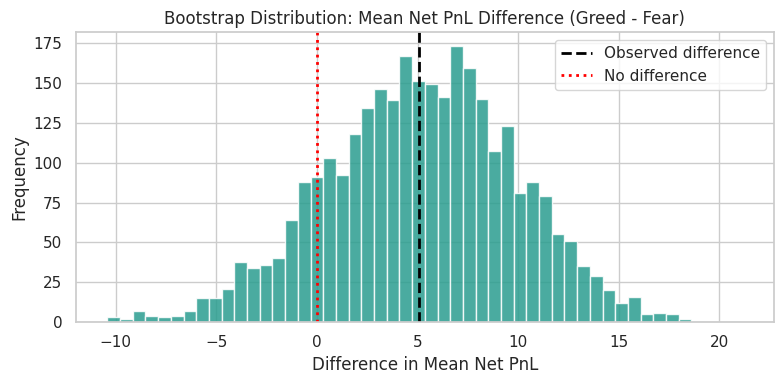

In [58]:
fear_vals = analysis_df.loc[analysis_df['sentiment_class'].str.contains('Fear', case=False, na=False), 'net_pnl'].dropna().values
greed_vals = analysis_df.loc[analysis_df['sentiment_class'].str.contains('Greed', case=False, na=False), 'net_pnl'].dropna().values

print('Fear sample size:', len(fear_vals))
print('Greed sample size:', len(greed_vals))

if len(fear_vals) > 30 and len(greed_vals) > 30:
    n_boot = 3000
    rng = np.random.default_rng(42)

    fear_means = [rng.choice(fear_vals, size=len(fear_vals), replace=True).mean() for _ in range(n_boot)]
    greed_means = [rng.choice(greed_vals, size=len(greed_vals), replace=True).mean() for _ in range(n_boot)]
    diff = np.array(greed_means) - np.array(fear_means)

    ci_low, ci_high = np.percentile(diff, [2.5, 97.5])
    observed = greed_vals.mean() - fear_vals.mean()

    print(f'Observed mean difference (Greed - Fear): {observed:.6f}')
    print(f'95% bootstrap CI: [{ci_low:.6f}, {ci_high:.6f}]')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(diff, bins=50, color='#2A9D8F', alpha=0.85)
    ax.axvline(observed, color='black', linestyle='--', linewidth=2, label='Observed difference')
    ax.axvline(0, color='red', linestyle=':', linewidth=2, label='No difference')
    ax.set_title('Bootstrap Distribution: Mean Net PnL Difference (Greed - Fear)')
    ax.set_xlabel('Difference in Mean Net PnL')
    ax.set_ylabel('Frequency')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Insufficient Fear/Greed sample size for bootstrap comparison.')

## Time-of-Day Pattern by Sentiment

sentiment_class,Extreme Fear,Fear,Neutral,Greed,Extreme Greed
hour_ist,,,,,
0,-45.5840,49.9831,133.4820,15.2798,21.0044
1,212.7888,87.8428,-8.1283,8.7914,44.5072
2,39.8705,102.5939,-20.0042,16.8048,28.6893
3,0.7006,62.0243,68.1105,3.1995,81.6930
4,43.8456,10.8489,87.2152,18.4583,124.0943
5,0.5684,39.7842,59.6317,33.5831,51.0887
6,18.6805,30.8719,22.7690,20.1915,76.0796
7,65.2221,141.3709,51.9481,46.1066,17.2594
8,229.4878,60.3377,-12.0049,37.5355,64.4698


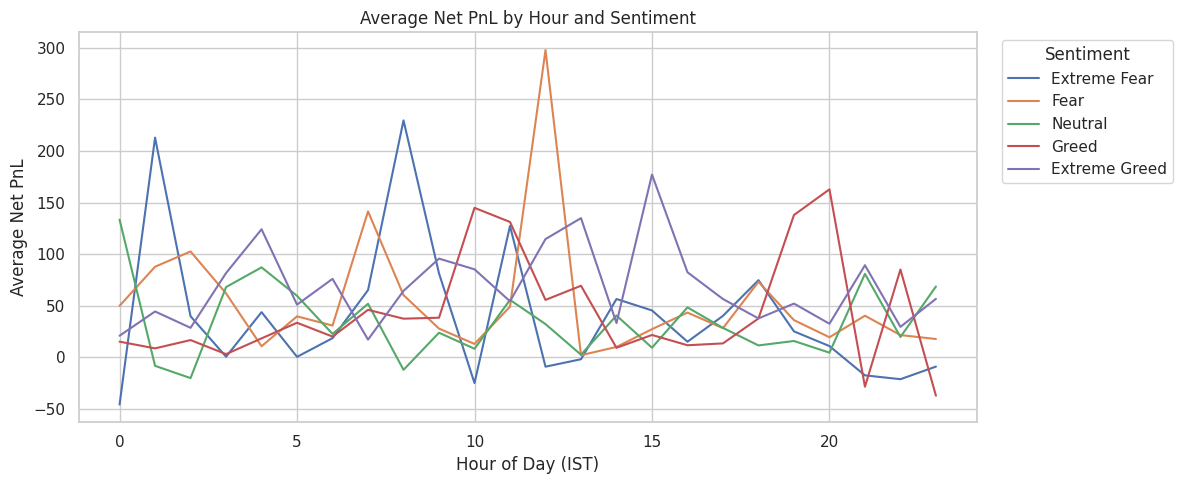

In [59]:
hourly = analysis_df.groupby(['hour_ist', 'sentiment_class'], observed=False).agg(
    avg_net_pnl=('net_pnl', 'mean'),
    trades=('account', 'count')
).reset_index()

# Keep only reasonably active hour-sentiment buckets
hourly_filtered = hourly[hourly['trades'] >= 20]

pivot_hour = hourly_filtered.pivot(index='hour_ist', columns='sentiment_class', values='avg_net_pnl')
display(pivot_hour.round(4).head(24))

fig, ax = plt.subplots(figsize=(12, 5))
pivot_hour.plot(ax=ax)
ax.set_title('Average Net PnL by Hour and Sentiment')
ax.set_xlabel('Hour of Day (IST)')
ax.set_ylabel('Average Net PnL')
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

<!-- ## 7) Final Insights and Strategy Recommendations -->

In [60]:
import os
import json

summary = perf_by_sentiment.copy()

label_candidates = ['sentiment_class', 'classification', 'sentiment', 'regime']
label_col = next((col for col in label_candidates if col in summary.columns), None)
metric_candidates = ['total_pnl', 'total_net_pnl', 'total_closed_pnl', 'avg_pnl', 'median_pnl']
metric_col = next((col for col in metric_candidates if col in summary.columns), None)

if label_col is None:
    raise KeyError(f'No usable sentiment label column found. Available columns: {list(summary.columns)}')
if metric_col is None:
    raise KeyError(f'No usable PnL column found. Available columns: {list(summary.columns)}')

best_sentiment = summary.loc[summary[metric_col].idxmax(), label_col] if len(summary) else 'N/A'
worst_sentiment = summary.loc[summary[metric_col].idxmin(), label_col] if len(summary) else 'N/A'

evidence = {
    'performance_by_sentiment': summary.round(4).to_dict(orient='records') if len(summary) else [],
    'label_column_used': label_col,
    'performance_metric_used': metric_col,
    'tail_risk': tail_risk.round(4).to_dict() if 'tail_risk' in globals() else {},
    'side_performance': side_perf.round(4).to_dict(orient='records') if 'side_perf' in globals() else [],
    'top_accounts': top_accounts.round(4).to_dict(orient='records') if 'top_accounts' in globals() else [],
    'top_coins': coin_sentiment.sort_values('total_pnl', ascending=False).head(10).round(4).to_dict(orient='records') if 'coin_sentiment' in globals() else [],
    'best_sentiment_by_metric': best_sentiment,
    'worst_sentiment_by_metric': worst_sentiment,
}

prompt = f'''You are a quantitative trading analyst. Write a concise, polished assignment conclusion from the evidence below.
Focus on: sentiment-performance relationship, strongest/weakest regimes, side behavior, and practical strategy recommendations.
Use short paragraphs or bullets. Do not mention that the summary is generated from code.

Evidence JSON:
{json.dumps(evidence, indent=2)}'''

def generate_ai_summary(prompt_text: str, api_key: str) -> str:
    if not api_key:
        raise RuntimeError('OpenAI API Key is required but not provided.')

    try:
        from openai import OpenAI
        client = OpenAI(api_key=api_key)
        response = client.chat.completions.create(
            model=os.getenv('OPENAI_MODEL', 'gpt-4o-mini'),
            messages=[
                {'role': 'system', 'content': 'You are a precise financial analysis assistant.'},
                {'role': 'user', 'content': prompt_text},
            ],
            temperature=0.3,
        )
        return response.choices[0].message.content.strip()
    except Exception as exc:
        raise RuntimeError(f'AI summary unavailable: {exc}')

# Prompt for API key securely if not already set in environment
from getpass import getpass
openai_api_key = os.getenv('OPENAI_API_KEY') or None
if not openai_api_key:
    try:
        openai_api_key = getpass('Enter OpenAI API key (input hidden): ')
    except Exception:
        openai_api_key = None

try:
    if openai_api_key:
        ai_summary = generate_ai_summary(prompt, openai_api_key)
        print(ai_summary)
    else:
        raise RuntimeError('OpenAI API key not provided')
except Exception as exc:
    print('AI summary could not be generated, using a data-driven fallback instead.')
    print('')
    print('Key Findings')
    print('-' * 60)
    print(f'1) Best sentiment regime by {metric_col}: {best_sentiment}')
    print(f'2) Weakest sentiment regime by {metric_col}: {worst_sentiment}')
    if len(summary):
        print('3) Win rate by regime (%):')
        if 'win_rate' in summary.columns:
            for s, wr in summary.sort_values('win_rate', ascending=False).set_index(label_col)['win_rate'].items():
                print(f'   - {s}: {wr:.2f}%')
    print('')
    print('Actionable Strategy Ideas')
    print('-' * 60)
    print('1) Adapt risk by sentiment: reduce size in weaker sentiment regimes and scale in stronger regimes.')
    print('2) Use sentiment-aware filters: keep only setups (account/coin/hour) that remain profitable per regime.')
    print('3) Track net edge (PnL after fees), not just gross closed PnL, when evaluating strategies.')
    print('4) Apply account-level specialization: some accounts perform better in Fear while others in Greed.')
    print(f'Fallback reason: {exc}')

Enter OpenAI API key (input hidden): ··········
AI summary could not be generated, using a data-driven fallback instead.

Key Findings
------------------------------------------------------------
1) Best sentiment regime by total_pnl: Fear
2) Weakest sentiment regime by total_pnl: Extreme Fear
3) Win rate by regime (%):
   - Extreme Greed: 46.49%
   - Fear: 42.08%
   - Neutral: 39.70%
   - Greed: 38.48%
   - Extreme Fear: 37.06%

Actionable Strategy Ideas
------------------------------------------------------------
1) Adapt risk by sentiment: reduce size in weaker sentiment regimes and scale in stronger regimes.
2) Use sentiment-aware filters: keep only setups (account/coin/hour) that remain profitable per regime.
3) Track net edge (PnL after fees), not just gross closed PnL, when evaluating strategies.
4) Apply account-level specialization: some accounts perform better in Fear while others in Greed.
Fallback reason: AI summary unavailable: Error code: 429 - {'error': {'message': 'You 